<a href="https://colab.research.google.com/github/hoangchaugiahan/FUZZYLOGIC/blob/main/VNeseBanknotes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense,Dropout

In [ ]:
datagen = ImageDataGenerator(rescale=1.0/255)
generator = datagen.flow_from_directory(
    '/content/drive/MyDrive/VND',
    target_size=(32, 32),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True
)
test_generator = datagen.flow_from_directory(
    '/content/drive/MyDrive/VND',
    target_size=(32, 32),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=10000,
    shuffle=False
)

class_labels = ['2.000 VND', '50.000 VND', '100.000 VND', '200.000 VND', '500.000 VND']
X_batch, y_batch = next(generator)
X_batch_flat = X_batch.reshape(X_batch.shape[0], -1)
print("Input shape for ANN:", X_batch_flat.shape)
print("Label shape (one-hot):", y_batch.shape)

Found 28 images belonging to 5 classes.
Found 28 images belonging to 5 classes.
Input shape for ANN: (28, 3072)
Label shape (one-hot): (28, 5)


In [ ]:
test_generator = datagen.flow_from_directory(
    '/content/drive/MyDrive/VND',
    target_size=(32, 32),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=10000,
    shuffle=False
)
x_train, y_train = next(generator)
x_test, y_test = next(test_generator)
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)
model = Sequential([
    Dense(256, activation='relu', input_shape=(32*32*3,)),
    Dense(128, activation='relu'),
    Dense(generator.num_classes, activation='softmax')

])

Found 28 images belonging to 5 classes.
(28, 3072) (28, 5)
(28, 3072) (28, 5)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=300, batch_size=100, validation_data=(x_test, y_test))

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1786 - loss: 2.0130 - val_accuracy: 0.2143 - val_loss: 3.4307
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.2143 - loss: 3.4307 - val_accuracy: 0.1786 - val_loss: 3.1263
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.1786 - loss: 3.1263 - val_accuracy: 0.2500 - val_loss: 2.6492
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.2500 - loss: 2.6492 - val_accuracy: 0.2857 - val_loss: 2.1144
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.2857 - loss: 2.1144 - val_accuracy: 0.4643 - val_loss: 1.4859
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.4643 - loss: 1.4859 - val_accuracy: 0.3929 - val_loss: 1.4901
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.3929 - loss: 1.4901 - val_accuracy: 0.4286 - val_loss: 1.5000
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.4286 - loss: 1.5000 - val_accuracy: 0.3929 - val_

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
Dự đoán: 2.000


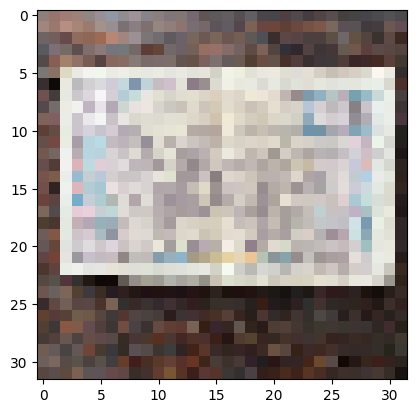

In [ ]:
img=load_img('/content/drive/MyDrive/VND/2.000/IMG_8769.PNG', target_size=(32,32))
plt.imshow(img)
img=img_to_array(img)
img_flatten=img.reshape(1,32*32*3)
img = img_to_array(img)
img_flatten = img.reshape(1, 32*32*3)
img_flatten = img_flatten.astype('float32') /255
y_pred_prob = model.predict(img_flatten)
predicted_class_index = int(np.argmax(y_pred_prob))
class_labels = list(generator.class_indices.keys())
print("Dự đoán:", class_labels[predicted_class_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Dự đoán: 10.000


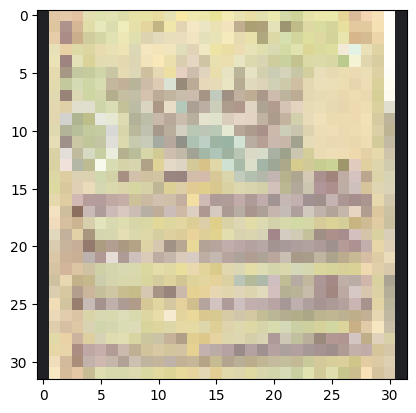

In [ ]:
img=load_img('/content/drive/MyDrive/VND/10.000/IMG_8782.PNG', target_size=(32,32))
plt.imshow(img)
img=img_to_array(img)
img_flatten=img.reshape(1,32*32*3)
img = img_to_array(img)
img_flatten = img.reshape(1, 32*32*3)
img_flatten = img_flatten.astype('float32') /255
y_pred_prob = model.predict(img_flatten)
predicted_class_index = int(np.argmax(y_pred_prob))
class_labels = list(generator.class_indices.keys())
print("Dự đoán:", class_labels[predicted_class_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Dự đoán: 50.000


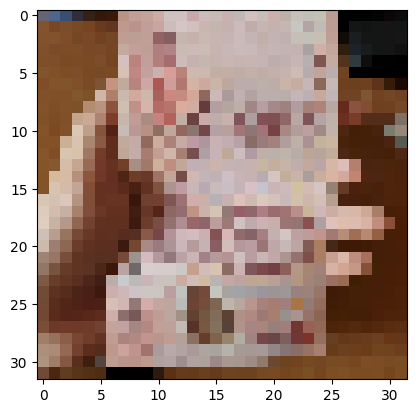

In [ ]:
img=load_img('/content/drive/MyDrive/VND/50.000/IMG_8775.PNG', target_size=(32,32))
plt.imshow(img)
img=img_to_array(img)
img_flatten=img.reshape(1,32*32*3)
img = img_to_array(img)
img_flatten = img.reshape(1, 32*32*3)
img_flatten = img_flatten.astype('float32') /255
y_pred_prob = model.predict(img_flatten)
predicted_class_index = int(np.argmax(y_pred_prob))
class_labels = list(generator.class_indices.keys())
print("Dự đoán:", class_labels[predicted_class_index])